In [1]:
import os
import xml.etree.ElementTree as ET

In [2]:
def convert(size,box):
    dw = 1./size[0]
    dh = 1./size[1]
    x = (box[0] + box[1])/2.0
    y = (box[2] + box[3])/2.0
    w =  box[1] - box[0]
    h =  box[3] - box[2]
    return (x*dw,y*dh,w*dw,h*dh)

classes = ['helmet','head','person']

    

In [3]:
def convert_annotation(xml_file, output_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    with open(output_file, "w") as out:
        for obj in root.iter("object"):
            cls = obj.find("name").text.lower()
            if cls not in classes:
                continue
            cls_id = classes.index(cls)

            xmlbox = obj.find("bndbox")
            b = (
                float(xmlbox.find("xmin").text),
                float(xmlbox.find("xmax").text),
                float(xmlbox.find("ymin").text),
                float(xmlbox.find("ymax").text)
            )

            bb = convert((w, h), b)
            out.write(f"{cls_id} {' '.join(map(str, bb))}\n")

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations/hard_hat_workers1531.xml
/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations/hard_hat_workers4092.xml
/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations/hard_hat_workers2006.xml
/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations/hard_hat_workers3414.xml
/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations/hard_hat_workers4190.xml
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers4991.png
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers3833.png
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers1675.png
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers4122.png
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers4460.png


In [5]:
xml_folder = "/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations"
images_path = "/kaggle/input/datasets/andrewmvd/hard-hat-detection/images"
labels_path = "/kaggle/working/labels"

In [6]:
os.makedirs(labels_path, exist_ok=True)

for xml_file in os.listdir(xml_folder):
    if xml_file.endswith(".xml"):
        xml_path = os.path.join(xml_folder, xml_file)
        txt_path = os.path.join(labels_path, xml_file.replace(".xml", ".txt"))

        convert_annotation(xml_path, txt_path)

In [7]:
import shutil
from sklearn.model_selection import train_test_split

base_path = "/kaggle/working/dataset"

os.makedirs(f"{base_path}/train/images", exist_ok=True)
os.makedirs(f"{base_path}/train/labels", exist_ok=True)
os.makedirs(f"{base_path}/val/images", exist_ok=True)
os.makedirs(f"{base_path}/val/labels", exist_ok=True)

In [8]:
images = [img for img in os.listdir(images_path) if img.endswith(".png")]

train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

In [9]:
def copy_files(img_list, split):
    for img in img_list:
        img_src = os.path.join(images_path, img)
        label_src = os.path.join(labels_path, img.replace(".png", ".txt"))

        img_dst = f"{base_path}/{split}/images/{img}"
        label_dst = f"{base_path}/{split}/labels/{img.replace('.png', '.txt')}"

        shutil.copy(img_src, img_dst)
        shutil.copy(label_src, label_dst)

copy_files(train_imgs, "train")
copy_files(val_imgs, "val")

In [10]:
data_yaml = """
train: /kaggle/working/dataset/train/images
val: /kaggle/working/dataset/val/images

nc: 3
names: ["helmet", "head", "person"]
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(data_yaml)

In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:0000:01


In [12]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,      
    amp=False     
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fafc9a2a1b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers1.png: 640x640 9 helmets, 7.2ms
Speed: 5.4ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


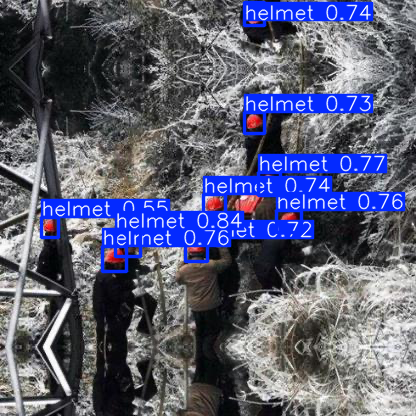

In [14]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

results = model("/kaggle/input/datasets/andrewmvd/hard-hat-detection/images/hard_hat_workers1.png")

results[0].show()

In [15]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

/kaggle/working/yolov8n.pt
/kaggle/working/runs/detect/train/weights/best.pt
/kaggle/working/runs/detect/train/weights/last.pt
